In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from DMTimeShardDataset import DMTimeShardDataset
import training
import training_models
from ensemble import TorchRejectionEnsemble
from skrejector import SNRDT_Rejector
from embedding_processing_models import build_embedding_processing
from rejector import EmbeddingRejector

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [7]:
dataset_cfg = {
    'output_dir': '/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs', 
    'prefix': 'B0531+21_59000_48386'
}

f_small_weights = '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth'
f_big_weights = '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_resnet18-003-0.993-0.993.pth'

print('Loading small model...')
small_model = training_models.models_htable['DM_time_binary_classificator_241002_3_GAP'](256, mode='dmt', dropout=False, device=device).to(device)
small_model.load_state_dict(torch.load(f_small_weights, map_location=device)['model_state_dict'])
small_model.eval()

print('Loading big model...')
big_model = training_models.models_htable['DM_time_binary_classificator_241002_5_GAP'](256, mode='ft', dropout=False, device=device).to(device)
big_model.load_state_dict(torch.load(f_big_weights, map_location=device)['model_state_dict'])
big_model.eval()


Loading small model...
Loading big model...


DMTimeBinaryClassificator241002_5_GAP(
  (dropout_conv): Identity()
  (dropout_fc): Identity()
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
  (conv1b): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1))
  (conv2b): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(8, 12, kernel_size=(5, 5), stride=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc2): Linear(in_features=12, out_features=2, bias=True)
)

In [8]:
targets_file = 'unbalanced_val_routing_targets_cascaded_r1.npy'

if os.path.exists(targets_file):
    print('Loading existing routing targets...')
    routing_targets_val_np = np.load(targets_file)
    pulse_val_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split='val')
    pulse_val_dataset.labels = training.label_encoding(pulse_val_dataset.labels.astype(object))
    pulse_val_loader = DataLoader(pulse_val_dataset, batch_size=1024, shuffle=False, num_workers=2)
else:
    print('Generating routing targets (this could take a while)...')
    pulse_train_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split='train')
    pulse_train_dataset.labels = training.label_encoding(pulse_train_dataset.labels.astype(object))
    pulse_val_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split='val')
    pulse_val_dataset.labels = training.label_encoding(pulse_val_dataset.labels.astype(object))

    pulse_train_loader = DataLoader(pulse_train_dataset, batch_size=1024, shuffle=False, num_workers=2)
    pulse_val_loader = DataLoader(pulse_val_dataset, batch_size=1024, shuffle=False, num_workers=2)

    dummy_rejector = SNRDT_Rejector(device)
    rejection_ensemble = TorchRejectionEnsemble(small_model, big_model, p=0.8, rejector=dummy_rejector, calibration=False)
    _, routing_targets_val, _, _ = rejection_ensemble.prepare_fit(pulse_train_loader, pulse_val_loader)
    routing_targets_val_np = routing_targets_val.cpu().numpy() if torch.is_tensor(routing_targets_val) else np.array(routing_targets_val)
    np.save(targets_file, routing_targets_val_np)

y_true = np.asarray(routing_targets_val_np).astype(int)
print(f'Done! True labels loaded, shape: {y_true.shape}')

Loading existing routing targets...
Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
Done! True labels loaded, shape: (172032,)


In [9]:
rejector_checkpoints = {
    'conv_mlp': {
        'path': '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_3_GAP_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker2_trial3-042-0.712-0.635.pth',
        'kwargs': {'model_name': 'conv_mlp', 'cnn_channels': 64, 'extra_conv': False, 'pool_size': 7, 'hidden_dim': 64}
    },
    'spatial_pool_mlp': {
        'path': '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_checkpoints/prot-run_embedding_3_GAP_spatial_pool_mlp_lr1.47e-05_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden128_worker3_trial7-045-0.650-0.628.pth',
        'kwargs': {'model_name': 'spatial_pool_mlp', 'pool_size': 7, 'pool_type': 'avg', 'hidden_dim': 128}
    },
    'pooled_mlp_128_64': {
        'path': '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_checkpoints/prot-run_embedding_3_GAP_pooled_mlp_128_64_lr1.90e-05_wd0.00e+00_drop0.0_hidden128_64_worker0_trial0-018-0.601-0.586.pth',
        'kwargs': {'model_name': 'pooled_mlp_128_64'}
    },
    'conv_gap': {
        'path': '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_checkpoints/prot-run_embedding_3_GAP_conv_gap_lr5.99e-05_wd0.00e+00_drop0.0_channels64_extraFalse_worker1_trial4-052-0.600-0.583.pth',
        'kwargs': {'model_name': 'conv_gap', 'cnn_channels': 64, 'extra_conv': False}
    }
}


In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    auc,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint


def get_rejector_state_dict(ckpt):
    state_dict = extract_state_dict(ckpt)

    clean_dict = {}
    for k, v in state_dict.items():
        if k.startswith("1.net."):
            clean_dict[k.replace("1.net.", "net.")] = v
        elif k.startswith("1."):
            clean_dict[k.replace("1.", "")] = v
        elif k.startswith("embedding_processing."):
            clean_dict[k.replace("embedding_processing.", "")] = v

    if len(clean_dict) == 0:
        return state_dict

    return clean_dict


def compute_pr_curve_from_scores(y_true, scores):
    """
    y_true:
        1 = reject, also f_small falsch
        0 = accept, also f_small korrekt

    scores:
        größerer Score = stärkerer Hinweis auf reject
        (hier: reject probability in [0, 1])
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # Average Precision ist die übliche PR-Metrik bei Imbalance.
    ap = average_precision_score(y_true, scores)

    # Optional: trapezförmige Fläche unter der gezeichneten Kurve.
    # Nicht identisch zu AP, aber manchmal als PR-AUC berichtet.
    pr_auc_trapz = auc(recall, precision)

    positive_rate = y_true.mean()

    return precision, recall, thresholds, ap, pr_auc_trapz, positive_rate


def print_threshold_metrics(y_true, scores, threshold=0.5):
    """
    threshold bezieht sich auf reject probability in [0, 1].
    threshold = 0.5 entspricht argmax.
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    y_pred = (scores >= threshold).astype(int)

    precision_r = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_r = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    reject_rate = y_pred.mean()
    positive_rate = y_true.mean()

    print(f"\nMetrics at threshold = {threshold:.4f}")
    print(f"Positive rate / true reject share: {positive_rate:.4f}")
    print(f"Predicted reject rate:            {reject_rate:.4f}")
    print(f"Precision reject=1:               {precision_r:.4f}")
    print(f"Recall reject=1:                  {recall_r:.4f}")
    print(f"F1 reject=1:                      {f1_r:.4f}")
    print()
    print("Confusion matrix for routing target")
    print("Rows = true, columns = predicted")
    print("          pred_accept   pred_reject")
    print(f"true_accept   {tn:10d}   {fp:11d}")
    print(f"true_reject   {fn:10d}   {tp:11d}")

    return {
        "threshold": threshold,
        "positive_rate": positive_rate,
        "reject_rate": reject_rate,
        "precision_reject": precision_r,
        "recall_reject": recall_r,
        "f1_reject": f1_r,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def evaluate_rejector_model(model_name):
    print(f"\n--- Evaluating {model_name} ---")
    info = rejector_checkpoints[model_name]

    rej_model, hook = build_embedding_processing(in_channels=12, **info["kwargs"])
    rej_model.to(device)
    rej_model.eval()

    ckpt = torch.load(info["path"], map_location=device)
    rej_model.load_state_dict(get_rejector_state_dict(ckpt))

    all_logits = []

    small_model.eval()

    with torch.no_grad():
        for batch in tqdm(pulse_val_loader):
            data_input = small_model.features(batch)

            if data_input.dim() == 3:
                data_input = data_input.unsqueeze(0)

            features = getattr(small_model, hook)(data_input)

            if features.dim() == 3:
                features = features.unsqueeze(0)
            elif hook == "pooled_features" and features.dim() == 1:
                features = features.unsqueeze(0)

            logits = rej_model(features)
            all_logits.append(logits.detach().cpu().numpy())

    logits_np = np.concatenate(all_logits, axis=0)

    if logits_np.shape[0] != len(y_true):
        raise ValueError(
            f"Logit count {logits_np.shape[0]} does not match labels {len(y_true)}. "
            "Prüfe, ob y_true exakt aus demselben Val-Loader in derselben Reihenfolge stammt "
            "und ob pulse_val_loader shuffle=False verwendet."
        )

    # Klasse 1 ist reject.
    # scores sind reject probabilities in [0, 1].
    scores = torch.softmax(torch.from_numpy(logits_np), dim=1).numpy()[:, 1]

    precision, recall, thresholds, ap, pr_auc_trapz, positive_rate = compute_pr_curve_from_scores(
        y_true, scores
    )

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2, label=f"{model_name} (AP = {ap:.4f})")
    plt.axhline(
        positive_rate,
        linestyle="--",
        label=f"Random baseline = {positive_rate:.4f}"
    )
    plt.xlabel("Recall for reject class")
    plt.ylabel("Precision for reject class")
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

    print(f"Positive rate / true reject share: {positive_rate:.4f}")
    print(f"Average Precision AP:             {ap:.4f}")
    print(f"Trapezoidal PR-AUC:               {pr_auc_trapz:.4f}")

    threshold_0_metrics = print_threshold_metrics(y_true, scores, threshold=0.5)

    return {
        "model_name": model_name,
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "scores": scores,
        "ap": ap,
        "pr_auc_trapz": pr_auc_trapz,
        "positive_rate": positive_rate,
        "threshold_0_metrics": threshold_0_metrics,
    }


--- Evaluating conv_mlp ---


  0%|          | 0/168 [00:00<?, ?it/s]

100%|██████████| 168/168 [01:02<00:00,  2.69it/s]


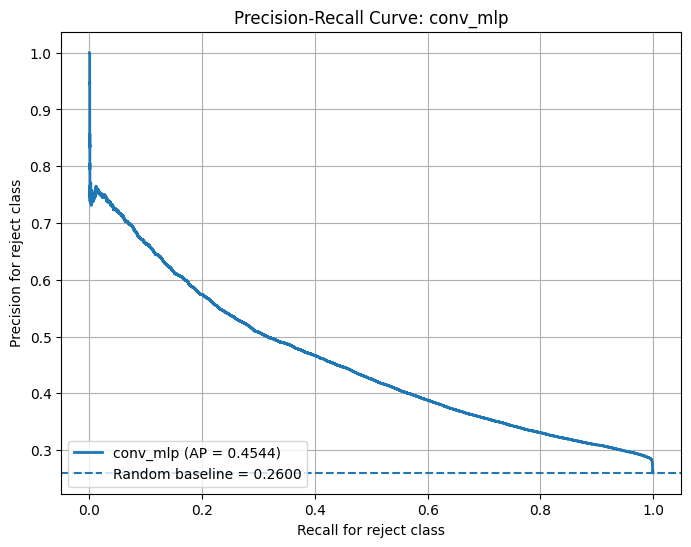

Positive rate / true reject share: 0.2600
Average Precision AP:             0.4544
Trapezoidal PR-AUC:               0.4544

Metrics at threshold = 0.5000
Positive rate / true reject share: 0.2600
Predicted reject rate:            0.3823
Precision reject=1:               0.3948
Recall reject=1:                  0.5805
F1 reject=1:                      0.4700

Confusion matrix for routing target
Rows = true, columns = predicted
          pred_accept   pred_reject
true_accept        87494         39803
true_reject        18765         25970


{'model_name': 'conv_mlp',
 'precision': array([0.26003883, 0.26004034, 0.26004185, ..., 1.        , 1.        ,
        1.        ]),
 'recall': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        4.47077233e-05, 2.23538616e-05, 0.00000000e+00]),
 'thresholds': array([5.43669683e-24, 6.65579537e-24, 1.56095378e-23, ...,
        9.99993801e-01, 9.99999404e-01, 9.99999881e-01]),
 'scores': array([0.01701714, 0.49719155, 0.5866361 , ..., 0.00667393, 0.32397696,
        0.53563   ], dtype=float32),
 'ap': 0.4543902357283611,
 'pr_auc_trapz': 0.45437274260018307,
 'positive_rate': 0.26003882998511907,
 'threshold_0_metrics': {'threshold': 0.5,
  'positive_rate': 0.26003882998511907,
  'reject_rate': 0.38233003162202384,
  'precision_reject': 0.39484286865431106,
  'recall_reject': 0.5805297865206215,
  'f1_reject': 0.4700112209070837,
  'tn': 87494,
  'fp': 39803,
  'fn': 18765,
  'tp': 25970}}

In [6]:
evaluate_rejector_model('conv_mlp')



--- Evaluating spatial_pool_mlp ---


100%|██████████| 168/168 [01:16<00:00,  2.19it/s]


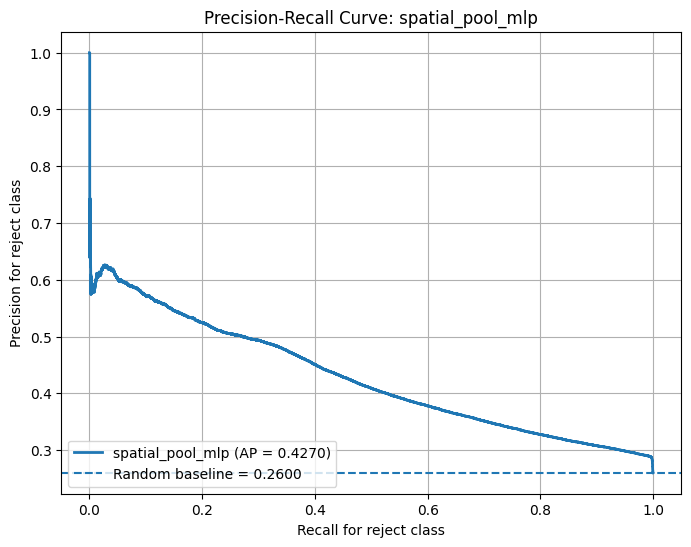

Positive rate / true reject share: 0.2600
Average Precision AP:             0.4270
Trapezoidal PR-AUC:               0.4270

Metrics at threshold = 0.5000
Positive rate / true reject share: 0.2600
Predicted reject rate:            0.4121
Precision reject=1:               0.3779
Recall reject=1:                  0.5989
F1 reject=1:                      0.4634

Confusion matrix for routing target
Rows = true, columns = predicted
          pred_accept   pred_reject
true_accept        83201         44096
true_reject        17944         26791


{'model_name': 'spatial_pool_mlp',
 'precision': array([0.26003883, 0.26004034, 0.26004185, ..., 1.        , 1.        ,
        1.        ]),
 'recall': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        2.68246340e-04, 2.45892478e-04, 0.00000000e+00]),
 'thresholds': array([5.10563147e-23, 6.37112403e-23, 6.41340634e-23, ...,
        9.99999523e-01, 9.99999881e-01, 1.00000000e+00]),
 'scores': array([0.05106381, 0.4707313 , 0.5109035 , ..., 0.01180671, 0.57478386,
        0.5244041 ], dtype=float32),
 'ap': 0.42697479251424253,
 'pr_auc_trapz': 0.42695468815672627,
 'positive_rate': 0.26003882998511907,
 'threshold_0_metrics': {'threshold': 0.5,
  'positive_rate': 0.26003882998511907,
  'reject_rate': 0.4120570591517857,
  'precision_reject': 0.3779395375738852,
  'recall_reject': 0.5988823069185202,
  'f1_reject': 0.46342391586376297,
  'tn': 83201,
  'fp': 44096,
  'fn': 17944,
  'tp': 26791}}

In [7]:
evaluate_rejector_model('spatial_pool_mlp')



--- Evaluating pooled_mlp_128_64 ---


  0%|          | 0/168 [00:00<?, ?it/s]

100%|██████████| 168/168 [00:56<00:00,  2.96it/s]


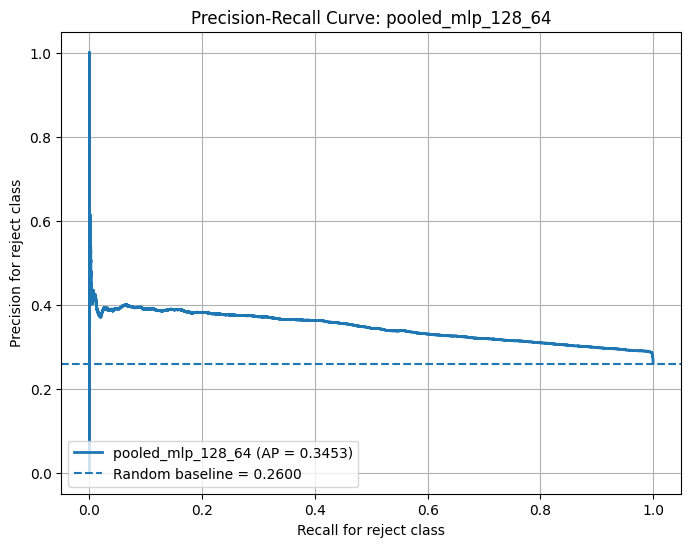

Positive rate / true reject share: 0.2600
Average Precision AP:             0.3453
Trapezoidal PR-AUC:               0.3453

Metrics at threshold = 0.5000
Positive rate / true reject share: 0.2600
Predicted reject rate:            0.4397
Precision reject=1:               0.3356
Recall reject=1:                  0.5675
F1 reject=1:                      0.4218

Confusion matrix for routing target
Rows = true, columns = predicted
          pred_accept   pred_reject
true_accept        77035         50262
true_reject        19349         25386


{'model_name': 'pooled_mlp_128_64',
 'precision': array([0.26003883, 0.26004034, 0.26004185, ..., 0.5       , 0.        ,
        1.        ]),
 'recall': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        2.23538616e-05, 0.00000000e+00, 0.00000000e+00]),
 'thresholds': array([2.31431492e-14, 2.32649034e-14, 2.52650887e-14, ...,
        8.01909328e-01, 8.13363254e-01, 8.17016244e-01]),
 'scores': array([0.07371254, 0.5405189 , 0.6758975 , ..., 0.05699489, 0.7041448 ,
        0.5024592 ], dtype=float32),
 'ap': 0.34531217244587836,
 'pr_auc_trapz': 0.345280559124446,
 'positive_rate': 0.26003882998511907,
 'threshold_0_metrics': {'threshold': 0.5,
  'positive_rate': 0.26003882998511907,
  'reject_rate': 0.43973214285714285,
  'precision_reject': 0.3355805837563452,
  'recall_reject': 0.5674751313289371,
  'f1_reject': 0.4217539021290382,
  'tn': 77035,
  'fp': 50262,
  'fn': 19349,
  'tp': 25386}}

In [8]:
evaluate_rejector_model('pooled_mlp_128_64')



--- Evaluating conv_gap ---


100%|██████████| 168/168 [00:56<00:00,  2.98it/s]


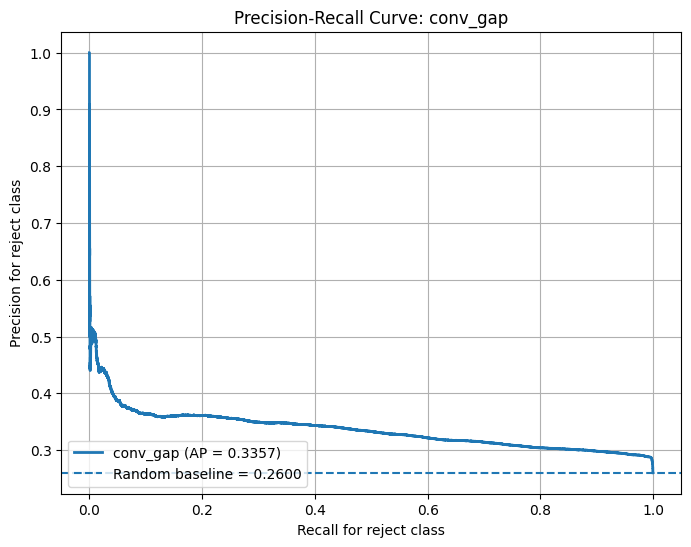

Positive rate / true reject share: 0.2600
Average Precision AP:             0.3357
Trapezoidal PR-AUC:               0.3357

Metrics at threshold = 0.5000
Positive rate / true reject share: 0.2600
Predicted reject rate:            0.5705
Precision reject=1:               0.3150
Recall reject=1:                  0.6911
F1 reject=1:                      0.4328

Confusion matrix for routing target
Rows = true, columns = predicted
          pred_accept   pred_reject
true_accept        60076         67221
true_reject        13820         30915


{'model_name': 'conv_gap',
 'precision': array([0.26003883, 0.26004034, 0.26004185, ..., 0.5       , 1.        ,
        1.        ]),
 'recall': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        2.23538616e-05, 2.23538616e-05, 0.00000000e+00]),
 'thresholds': array([1.82913050e-06, 1.92469201e-06, 1.99715078e-06, ...,
        9.05399024e-01, 9.08995807e-01, 9.17708993e-01]),
 'scores': array([0.08923233, 0.5847234 , 0.59884346, ..., 0.12462185, 0.53444535,
        0.5205784 ], dtype=float32),
 'ap': 0.33572909029690534,
 'pr_auc_trapz': 0.33570226238411205,
 'positive_rate': 0.26003882998511907,
 'threshold_0_metrics': {'threshold': 0.5,
  'positive_rate': 0.26003882998511907,
  'reject_rate': 0.5704520089285714,
  'precision_reject': 0.31502201027146004,
  'recall_reject': 0.6910696322789762,
  'f1_reject': 0.43276802150191435,
  'tn': 60076,
  'fp': 67221,
  'fn': 13820,
  'tp': 30915}}

In [9]:
evaluate_rejector_model('conv_gap')


# ensemble_val_acc(threshold)

100%|██████████| 168/168 [01:49<00:00,  1.53it/s]


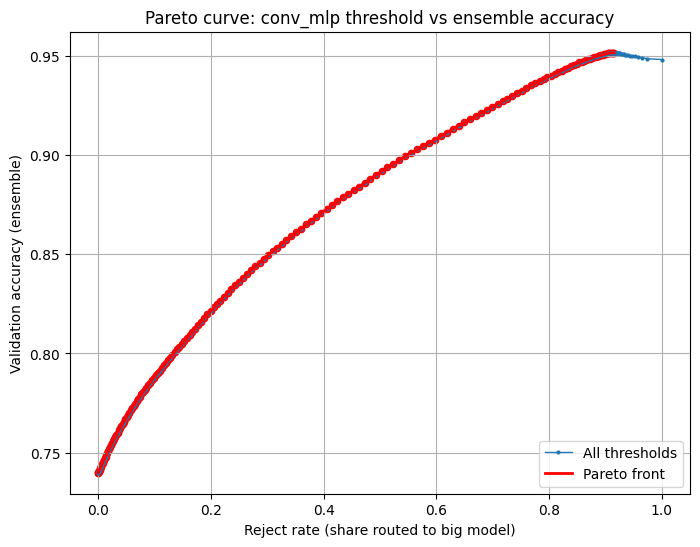

Best accuracy: 0.9514 at threshold 0.1055 (reject rate=0.9152)


In [11]:
# Pareto curve: conv_mlp threshold vs ensemble validation accuracy
conv_info = rejector_checkpoints['conv_mlp']
conv_model, hook = build_embedding_processing(in_channels=12, **conv_info['kwargs'])
conv_model.to(device)
conv_model.eval()

ckpt = torch.load(conv_info['path'], map_location=device)
conv_model.load_state_dict(get_rejector_state_dict(ckpt))

small_model.eval()
big_model.eval()

all_scores = []
all_small_preds = []
all_big_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(pulse_val_loader):
        labels = batch['label'].to(device)

        small_input = small_model.features(batch)
        if small_input.dim() == 3:
            small_input = small_input.unsqueeze(0)

        features = getattr(small_model, hook)(small_input)
        if features.dim() == 3:
            features = features.unsqueeze(0)
        elif hook == 'pooled_features' and features.dim() == 1:
            features = features.unsqueeze(0)

        rej_logits = conv_model(features)
        scores = torch.softmax(rej_logits, dim=1)[:, 1].detach()

        small_logits = small_model.classifier(small_input)
        small_pred = small_logits.argmax(dim=1)

        big_input = big_model.features(batch)
        if big_input.dim() == 3:
            big_input = big_input.unsqueeze(0)
        big_logits = big_model.classifier(big_input)
        big_pred = big_logits.argmax(dim=1)

        all_scores.append(scores.cpu())
        all_small_preds.append(small_pred.cpu())
        all_big_preds.append(big_pred.cpu())
        all_labels.append(labels.cpu())

scores_np = torch.cat(all_scores).numpy()
small_preds_np = torch.cat(all_small_preds).numpy()
big_preds_np = torch.cat(all_big_preds).numpy()
labels_np = torch.cat(all_labels).numpy()

thresholds = np.linspace(1.0, 0.0, 200)
accuracies = []
reject_rates = []

for t in thresholds:
    reject_mask = scores_np >= t
    y_pred = np.where(reject_mask, big_preds_np, small_preds_np)
    acc = (y_pred == labels_np).mean()
    accuracies.append(acc)
    reject_rates.append(reject_mask.mean())

reject_rates = np.array(reject_rates)
accuracies = np.array(accuracies)

order = np.argsort(reject_rates)
sorted_rr = reject_rates[order]
sorted_acc = accuracies[order]

pareto_rr = []
pareto_acc = []
best_acc = -np.inf
for rr, acc in zip(sorted_rr, sorted_acc):
    if acc >= best_acc - 1e-12:
        pareto_rr.append(rr)
        pareto_acc.append(acc)
        best_acc = acc

pareto_rr = np.array(pareto_rr)
pareto_acc = np.array(pareto_acc)

plt.figure(figsize=(8, 6))
plt.plot(reject_rates, accuracies, marker='o', markersize=2, linewidth=1, label='All thresholds')
plt.plot(pareto_rr, pareto_acc, color='red', linewidth=2, label='Pareto front')
plt.scatter(pareto_rr, pareto_acc, color='red', s=20)
plt.xlabel('Reject rate (share routed to big model)')
plt.ylabel('Validation accuracy (ensemble)')
plt.title('Pareto curve: conv_mlp threshold vs ensemble accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

best_idx = int(np.argmax(accuracies))
print(f'Best accuracy: {accuracies[best_idx]:.4f} at threshold {thresholds[best_idx]:.4f} (reject rate={reject_rates[best_idx]:.4f})')

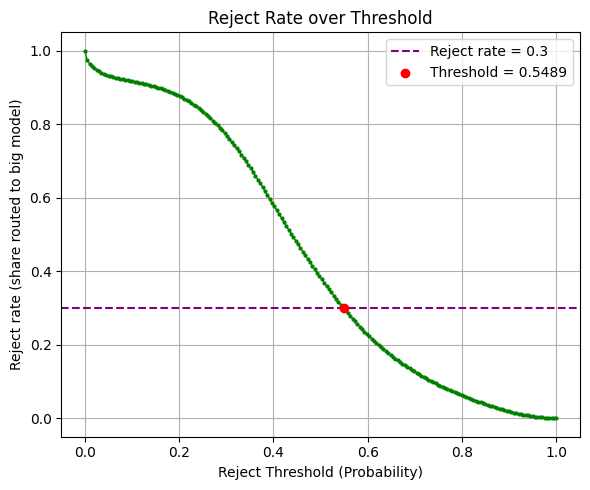

In [18]:
fig, ax2 = plt.subplots(1, figsize=(6, 5))
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Plot 1: Ensemble accuracy over thresholds
# ax1.plot(thresholds, accuracies, marker='o', markersize=2, linewidth=1, color='blue')
# ax1.set_xlabel('Reject Threshold (Probability)')
# ax1.set_ylabel('Validation accuracy (ensemble)')
# ax1.set_title('Accuracy over Threshold')
# ax1.grid(True)
# # Add a vertical dotted line for the threshold that gave the best accuracy
# ax1.axvline(thresholds[best_idx], color='red', linestyle='--', label=f'Best Threshold = {thresholds[best_idx]:.4f}')
# ax1.legend()

# Plot 2: Reject rate over thresholds
ax2.plot(thresholds, reject_rates, marker='o', markersize=2, linewidth=1, color='green')
ax2.set_xlabel('Reject Threshold (Probability)')
ax2.set_ylabel('Reject rate (share routed to big model)')
ax2.set_title('Reject Rate over Threshold')
ax2.grid(True)

target_reject_rate = 0.3
# np.interp erwartet ansteigende x-Werte.
# reject_rates steigen natürlicherweise an, da thresholds von 1.0 bis 0.0 absinken
thr_at_04 = np.interp(target_reject_rate, reject_rates, thresholds)

ax2.axhline(target_reject_rate, color='purple', linestyle='--', label=f'Reject rate = {target_reject_rate}')
ax2.scatter([thr_at_04], [target_reject_rate], color='red', zorder=5, label=f'Threshold = {thr_at_04:.4f}')

ax2.legend()

plt.tight_layout()
plt.show()

Threshold for ~30% reject rate: 0.548808 (achieved reject rate: 0.3000)


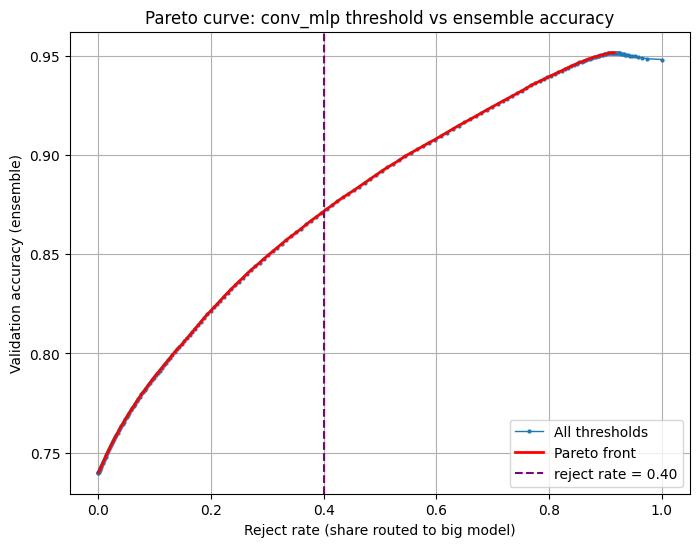

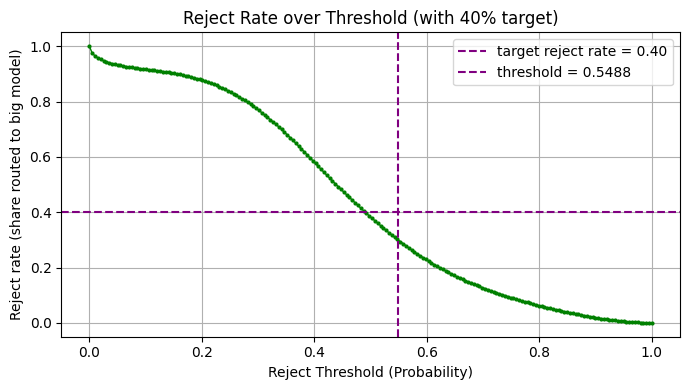

In [12]:
def threshold_for_reject_rate(scores, target_reject_rate=0.40):
    """Return a static threshold t so that ~target_reject_rate of samples satisfy scores >= t.

    scores:
        1D array-like of reject probabilities in [0, 1]
        (bigger => more likely reject)

    target_reject_rate:
        desired fraction in [0, 1] routed to big model.

    Notes:
        Uses the quantile of the score distribution:
            P(score >= t) ~= target_reject_rate  =>  t = quantile(scores, 1 - target_reject_rate)
        For ties/discrete scores the achieved rate can differ slightly.
    """
    scores = np.asarray(scores, dtype=float).reshape(-1)
    if not (0.0 <= target_reject_rate <= 1.0):
        raise ValueError('target_reject_rate must be in [0, 1]')
    if scores.size == 0:
        raise ValueError('scores must be non-empty')

    t = float(np.quantile(scores, 1.0 - float(target_reject_rate)))
    achieved = float((scores >= t).mean())
    return t, achieved


# Example for 40% reject rate
thr_40, rr_achieved_40 = threshold_for_reject_rate(scores_np, 0.30)
print(f"Threshold for ~30% reject rate: {thr_40:.6f} (achieved reject rate: {rr_achieved_40:.4f})")

# Optional: mark it in the plots
plt.figure(figsize=(8, 6))
plt.plot(reject_rates, accuracies, marker='o', markersize=2, linewidth=1, label='All thresholds')
plt.plot(pareto_rr, pareto_acc, color='red', linewidth=2, label='Pareto front')
plt.axvline(0.40, color='purple', linestyle='--', linewidth=1.5, label='reject rate = 0.40')
plt.xlabel('Reject rate (share routed to big model)')
plt.ylabel('Validation accuracy (ensemble)')
plt.title('Pareto curve: conv_mlp threshold vs ensemble accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# And show where that threshold lands on your (threshold -> reject rate) curve
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(thresholds, reject_rates, marker='o', markersize=2, linewidth=1, color='green')
ax.axhline(0.40, color='purple', linestyle='--', linewidth=1.5, label='target reject rate = 0.40')
ax.axvline(thr_40, color='purple', linestyle='--', linewidth=1.5, label=f'threshold = {thr_40:.4f}')
ax.set_xlabel('Reject Threshold (Probability)')
ax.set_ylabel('Reject rate (share routed to big model)')
ax.set_title('Reject Rate over Threshold (with 40% target)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# latency limit

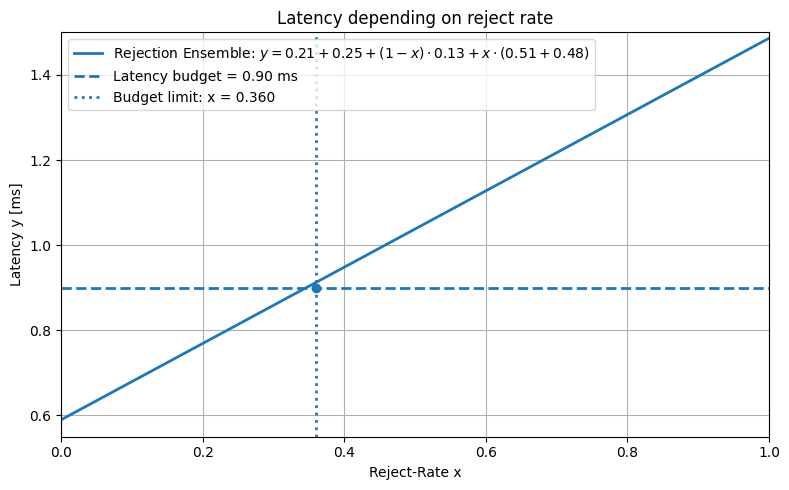

Budget: 0.900 ms
Max reject rate under budget: x = 0.3605 (36.05 %)
x = 0.0000 -> y = 0.5900 ms
x = 0.2500 -> y = 0.8050 ms
x = 0.3605 -> y = 0.9000 ms
x = 0.5000 -> y = 1.0200 ms
x = 0.7500 -> y = 1.2350 ms
x = 1.0000 -> y = 1.4500 ms


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Reject-Rate x zwischen 0 und 1
x = np.linspace(0, 1, 500)

# Latenzfunktion
y = 1 * 0.21 + 1 * 0.25 + (1 - x) * 0.13 + x * (0.51 + 0.21 + 0.38*((1-0.1098) * 0.10) + 0.1098 * 2.48)
#y = 1 * 0.21 + 1 * 0.25 + (1 - x_1) * 0.13 + x_1 * (0.51 + 0.21 + 0.38*((1-x_2) * 0.10) + x_2 * 2.48)

# Budget
budget = 0.9

# Schnittpunkt mit Budget berechnen
# y = 0.59 + 0.86x
x_budget = (budget - 0.59) / 0.86

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    y,
    linewidth=2,
    label=r"Rejection Ensemble: $y = 0.21 + 0.25 + (1-x)\cdot0.13 + x\cdot(0.51+0.48)$"
)

plt.axhline(
    budget,
    linestyle="--",
    linewidth=2,
    label=f"Latency budget = {budget:.2f} ms"
)

plt.axvline(
    x_budget,
    linestyle=":",
    linewidth=2,
    label=f"Budget limit: x = {x_budget:.3f}"
)

plt.scatter([x_budget], [budget], zorder=5)

plt.xlabel("Reject-Rate x")
plt.ylabel("Latency y [ms]")
plt.title("Latency depending on reject rate")
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0.55, 1.50)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Budget: {budget:.3f} ms")
print(f"Max reject rate under budget: x = {x_budget:.4f} ({x_budget * 100:.2f} %)")

for val in [0.00, 0.25, x_budget, 0.50, 0.75, 1.00]:
    lat = 0.21 + 0.25 + (1 - val) * 0.13 + val * (0.51 + 0.48)
    print(f"x = {val:.4f} -> y = {lat:.4f} ms")

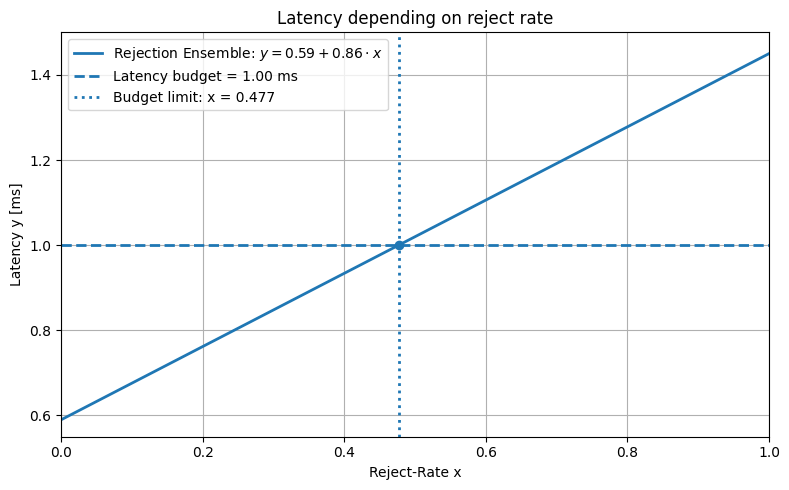

Budget: 1.000 ms
Max reject rate under budget: x = 0.4767 (47.67 %)
x = 0.0000 -> y = 0.5900 ms
x = 0.2500 -> y = 0.8050 ms
x = 0.4767 -> y = 1.0000 ms
x = 0.5000 -> y = 1.0200 ms
x = 0.7500 -> y = 1.2350 ms
x = 1.0000 -> y = 1.4500 ms


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Reject-Rate x zwischen 0 und 1
x = np.linspace(0, 1, 500)

# Latenzfunktion
#y = 1 * 0.21 + 1 * 0.25 + (1 - x) * 0.13 + x * (0.51 + 0.21 + 0.38*((1-0.1098) * 0.10) + 0.1098 * 2.48)
y = 0.59 + 0.86*x

# Budget
budget = 1.0

# Schnittpunkt mit Budget berechnen
# y = 0.59 + 0.86x
x_budget = (budget - 0.59) / 0.86

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    y,
    linewidth=2,
    label=r"Rejection Ensemble: $y = 0.59 + 0.86 \cdot x$"
)

plt.axhline(
    budget,
    linestyle="--",
    linewidth=2,
    label=f"Latency budget = {budget:.2f} ms"
)

plt.axvline(
    x_budget,
    linestyle=":",
    linewidth=2,
    label=f"Budget limit: x = {x_budget:.3f}"
)

plt.scatter([x_budget], [budget], zorder=5)

plt.xlabel("Reject-Rate x")
plt.ylabel("Latency y [ms]")
plt.title("Latency depending on reject rate")
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0.55, 1.50)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Budget: {budget:.3f} ms")
print(f"Max reject rate under budget: x = {x_budget:.4f} ({x_budget * 100:.2f} %)")

for val in [0.00, 0.25, x_budget, 0.50, 0.75, 1.00]:
    lat = 0.21 + 0.25 + (1 - val) * 0.13 + val * (0.51 + 0.48)
    print(f"x = {val:.4f} -> y = {lat:.4f} ms")